In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

filename = next(iter(uploaded))

df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

df.head()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv
Dataset loaded successfully!
Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape:
(7043, 21)

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values:
cus

In [ ]:
print("TotalCharges data type before conversion:")
print(df["TotalCharges"].dtype)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("\nTotalCharges data type after conversion:")
print(df["TotalCharges"].dtype)

print("\nMissing values created in TotalCharges:")
print(df["TotalCharges"].isnull().sum())

TotalCharges data type before conversion:
object

TotalCharges data type after conversion:
float64

Missing values created in TotalCharges:
11


In [ ]:
df[df["TotalCharges"].isnull()][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]
]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


In [ ]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("Remaining missing values in TotalCharges:")
print(df["TotalCharges"].isnull().sum())

Remaining missing values in TotalCharges:
0


In [ ]:
# Numerical columns
numerical_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

summary = pd.DataFrame({
    "Mean": df[numerical_cols].mean(),
    "Median": df[numerical_cols].median(),
    "Variance": df[numerical_cols].var(),
    "Standard Deviation": df[numerical_cols].std(),
    "Skewness": df[numerical_cols].skew()
})

summary

,Mean,Median,Variance,Standard Deviation,Skewness
SeniorCitizen,0.162147,0.00,1.358745e-01,0.368612,1.833633
tenure,32.371149,29.00,6.031681e+02,24.559481,0.239540
MonthlyCharges,64.761692,70.35,9.054109e+02,30.090047,-0.220524
TotalCharges,2279.734304,1394.55,5.138357e+06,2266.794470,0.963235


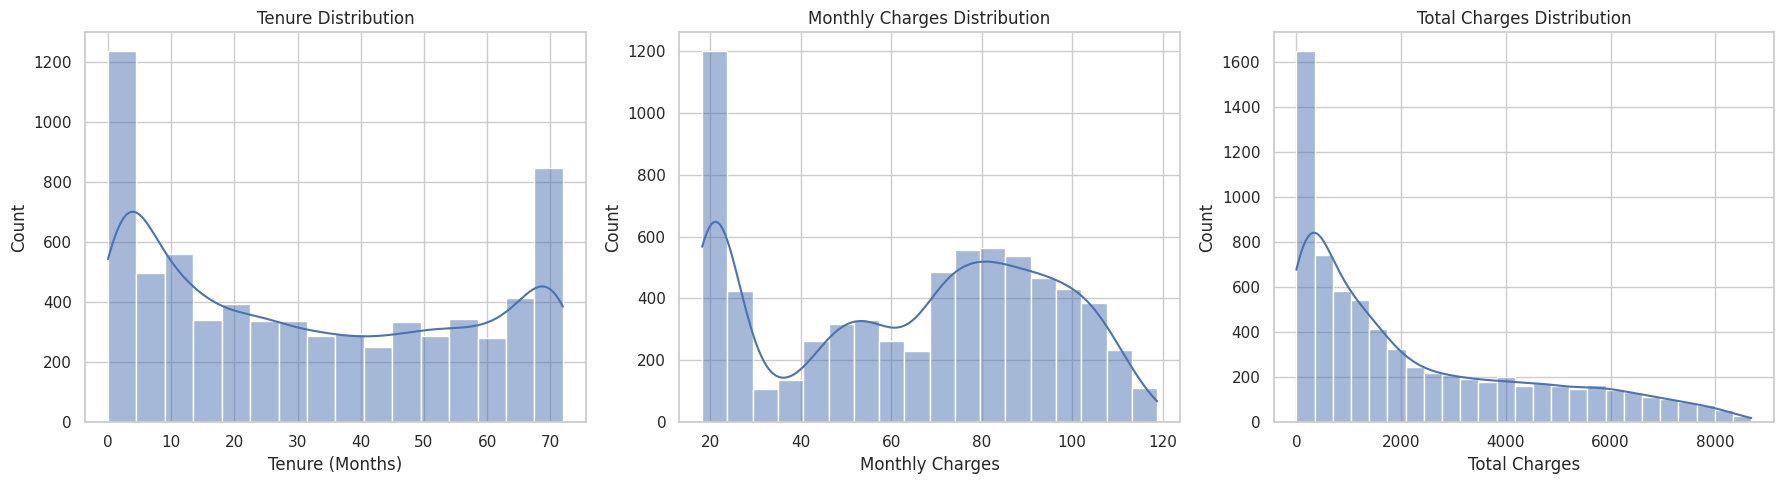

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df["tenure"], kde=True, ax=axes[0])
axes[0].set_title("Tenure Distribution")
axes[0].set_xlabel("Tenure (Months)")

sns.histplot(df["MonthlyCharges"], kde=True, ax=axes[1])
axes[1].set_title("Monthly Charges Distribution")
axes[1].set_xlabel("Monthly Charges")

sns.histplot(df["TotalCharges"], kde=True, ax=axes[2])
axes[2].set_title("Total Charges Distribution")
axes[2].set_xlabel("Total Charges")

plt.tight_layout()
plt.show()

In [ ]:
for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    print(col, "Skewness:", round(df[col].skew(), 3))

tenure Skewness: 0.24
MonthlyCharges Skewness: -0.221
TotalCharges Skewness: 0.963


In [ ]:
numerical_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

summary = pd.DataFrame({
    "Mean": df[numerical_cols].mean(),
    "Median": df[numerical_cols].median(),
    "Variance": df[numerical_cols].var(),
    "Standard Deviation": df[numerical_cols].std(),
    "Skewness": df[numerical_cols].skew()
})

summary

,Mean,Median,Variance,Standard Deviation,Skewness
SeniorCitizen,0.162147,0.00,1.358745e-01,0.368612,1.833633
tenure,32.371149,29.00,6.031681e+02,24.559481,0.239540
MonthlyCharges,64.761692,70.35,9.054109e+02,30.090047,-0.220524
TotalCharges,2279.734304,1394.55,5.138357e+06,2266.794470,0.963235


### Distribution Interpretation

The skewness analysis shows that TotalCharges has the clearest right-skewed distribution, with a skewness value of 0.963. This occurs because customers with longer tenure can accumulate substantially higher total charges.

Tenure has only mild positive skewness (0.240), while MonthlyCharges has mild negative skewness (-0.221). These values are relatively close to zero, indicating that both distributions are approximately symmetric compared with TotalCharges.

For skewed data, the mean can be influenced by extreme values, so the median can sometimes provide a more representative measure of the typical observation.

In [ ]:
print("Churn Counts:")
print(df["Churn"].value_counts())

print("\nChurn Percentage:")
print((df["Churn"].value_counts(normalize=True) * 100).round(2))

Churn Counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


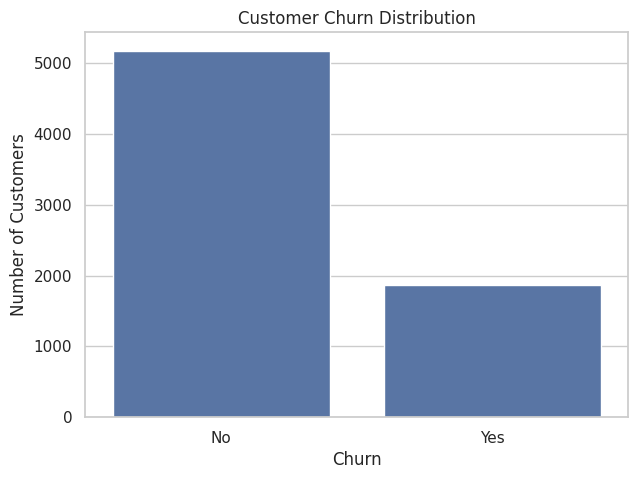

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

## Churn Distribution Interpretation

The target variable `Churn` is imbalanced. Approximately 73.46% of customers are classified as `No Churn`, while 26.54% are classified as `Churn`.

Because the churn class represents only about one-quarter of the dataset, accuracy alone can be misleading. A classifier that always predicts `No Churn` can achieve approximately 73.46% accuracy without identifying any churned customers. Therefore, precision, recall, and F1-score for the churn class should also be considered when evaluating classification models.


In [ ]:
contract_rate = (
    df.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

contract_rate

,Contract,ChurnRate
0,Month-to-month,42.709677
1,One year,11.269518
2,Two year,2.831858


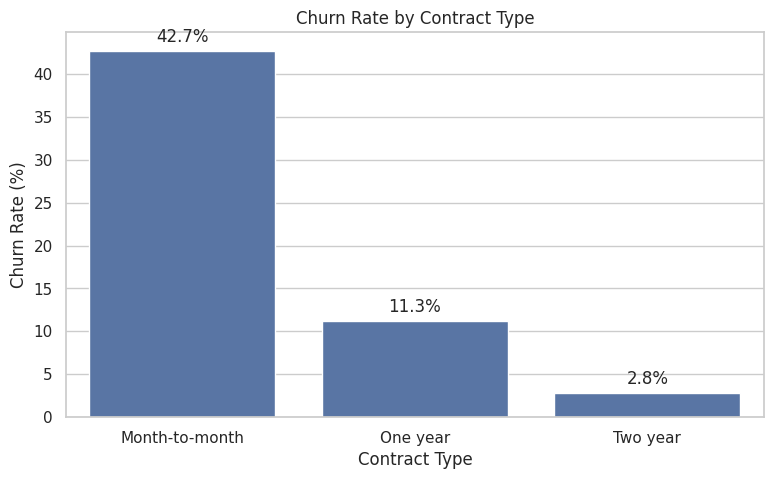

In [ ]:
plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=contract_rate,
    x="Contract",
    y="ChurnRate"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(contract_rate["ChurnRate"]):
    ax.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.show()

## Contract Type vs Churn

Contract type shows a clear relationship with customer churn. Customers with month-to-month contracts have a higher churn rate compared with customers on one-year and two-year contracts. This suggests that contract commitment is an important feature to consider when analyzing and predicting customer churn. However, this analysis shows an association between contract type and churn and does not prove that contract type itself causes customers to leave.


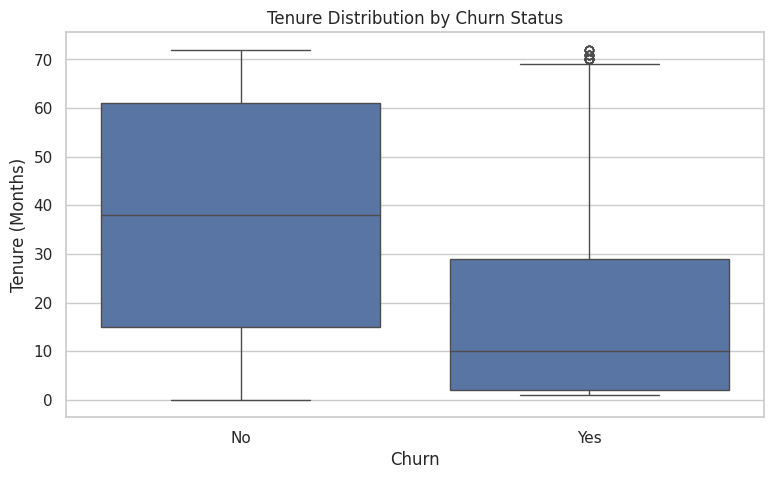

In [ ]:
plt.figure(figsize=(9,5))

sns.boxplot(data=df, x="Churn", y="tenure")

plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

In [ ]:
df.groupby("Churn")["tenure"].agg(["mean", "median", "std"])

,mean,median,std
Churn,,,
No,37.569965,38.0,24.113777
Yes,17.979133,10.0,19.531123


## Tenure vs Churn

Tenure shows a noticeable relationship with customer churn. Customers who did not churn have a much higher average tenure of approximately 37.57 months, compared with 17.98 months for customers who churned. The median tenure is also substantially higher for customers who stayed (38 months) than for customers who churned (10 months). This indicates that newer customers tend to have a higher likelihood of churn in this dataset. However, this analysis shows an association and does not establish that shorter tenure directly causes churn.


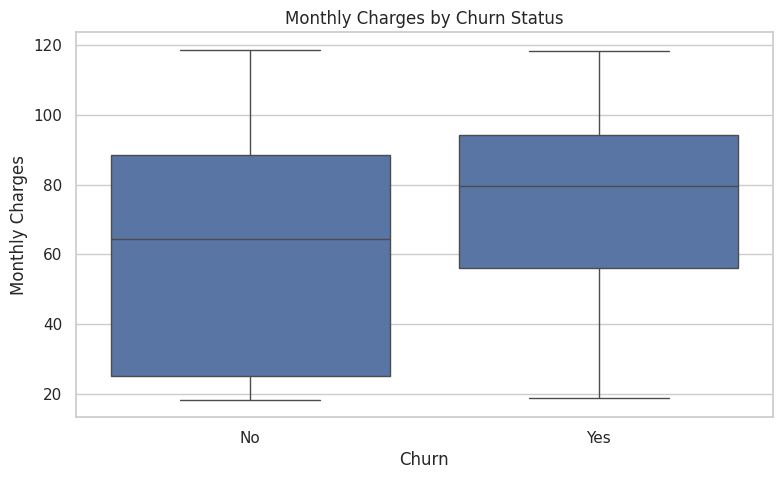

In [ ]:
plt.figure(figsize=(9,5))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

## Monthly Charges vs Churn

Monthly charges show a noticeable relationship with customer churn. Customers who churned had a higher average monthly charge of approximately $74.44 compared with $61.27 for customers who did not churn. The median monthly charge was also higher for churned customers ($79.65) than for customers who stayed ($64.43). This suggests that customers with higher monthly charges may be more likely to churn in this dataset. However, this relationship represents an association and does not prove that higher charges directly cause churn.


In [ ]:
df.groupby("Churn")["MonthlyCharges"].agg(["mean", "median", "std"])

,mean,median,std
Churn,,,
No,61.265124,64.425,31.092648
Yes,74.441332,79.650,24.666053


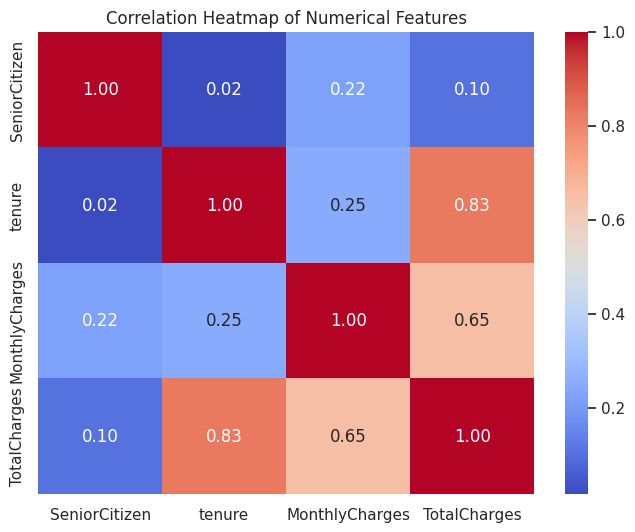

In [ ]:
numerical_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

corr = df[numerical_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

## Correlation Heatmap Interpretation

The correlation heatmap shows that `tenure` and `TotalCharges` have a strong positive correlation of approximately 0.83. This is expected because customers with longer tenure generally accumulate higher total charges. `MonthlyCharges` and `TotalCharges` also have a moderately strong positive correlation of approximately 0.65. In contrast, `tenure` and `MonthlyCharges` have a relatively weak positive correlation of approximately 0.25, while `SeniorCitizen` has weak correlations with the other numerical features.

The strongest relationship between `tenure` and `TotalCharges` is important because `TotalCharges` is largely derived from the customer's tenure and monthly charges. Therefore, these variables contain overlapping information and should be considered carefully during later feature engineering.


In [20]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

X = df.drop(columns=["Churn"])
y = df["Churn"]

dummy = DummyClassifier(strategy="most_frequent")

dummy.fit(X, y)

y_pred = dummy.predict(X)

accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred, pos_label="Yes", zero_division=0)
recall = recall_score(y, y_pred, pos_label="Yes", zero_division=0)
f1 = f1_score(y, y_pred, pos_label="Yes", zero_division=0)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Accuracy : 0.7346
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0


## Majority-Class Baseline Interpretation

The majority-class baseline achieves an accuracy of 73.46% by always predicting `No Churn`, which is the majority class in the dataset. However, the classifier does not predict any customers as `Churn`. Therefore, precision, recall, and F1-score for the churn class are all 0.00.

This demonstrates why accuracy alone can be misleading for this classification problem. Although the baseline achieves 73.46% accuracy, it fails to identify any customers who actually churned. Therefore, future classification models should be evaluated using accuracy together with precision, recall, and F1-score, particularly for the `Churn` class.
